In [1]:
# import libraries and moduels
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# from pandas.plotting import scatter_matrix
# import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.impute import SimpleImputer, KNNImputer
# from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Building and Evaluating Machine Learning Models

This section focuses on the process of building, training, and evaluating various machine learning regression models for housing price prediction, using preprocessed data. We will cover model training, evaluation, hyperparameter tuning, and feature importance analysis.

### Learning Objectives

By the end of this notebook, you will be able to:

1.  **Implement and evaluate different regression models**, including Linear Regression, Lasso Regression, Decision Trees, Random Forests, and Gradient Boosting.
2.  **Understand and interpret model performance metrics** such as Mean Squared Error (MSE) and R-squared.
3.  **Visualize model predictions** against observed values to assess model fit.
4.  **Identify and analyze important features** contributing to predictions for various models.
5.  **Perform hyperparameter tuning** using GridSearchCV to optimize model performance.
6.  **Understand the tradeoffs in model selection**,
7   **Understand the issue issue of overfitting**.


In [2]:
# IMPORTANT NOTE: If you keep buiding your project under the same notebook for data pre-processing, the data are already there.
# I am doing this to keep the data pre-processing part and modeling part separate for pedagogical reasons.
# Load the data
url_X_train = "https://raw.githubusercontent.com/sparks5969/advanced_data_analysis/refs/heads/main/X_train_ready.csv"
url_X_test = "https://raw.githubusercontent.com/sparks5969/advanced_data_analysis/refs/heads/main/X_test_ready.csv"
url_y_train = "https://raw.githubusercontent.com/sparks5969/advanced_data_analysis/refs/heads/main/y_train.csv"
url_y_test = "https://raw.githubusercontent.com/sparks5969/advanced_data_analysis/refs/heads/main/y_test.csv"
url_raw = "https://raw.githubusercontent.com/sparks5969/advanced_data_analysis/refs/heads/main/raw_train.csv"
X_train_ready = pd.read_csv(url_X_train)
X_test_ready = pd.read_csv(url_X_test)
y_train = pd.read_csv(url_y_train)
y_test = pd.read_csv(url_y_test)
raw = pd.read_csv(url_raw)

# reset the first colmun of X_train_ready as the index
X_train_ready.set_index(X_train_ready.columns[0], inplace=True)
X_train_ready.index.name = None

# reset the first column of X_test_ready as the index
X_test_ready.set_index(X_test_ready.columns[0], inplace=True)
X_test_ready.index.name = None

# reset the first column of y_train as the index
y_train.set_index(y_train.columns[0], inplace=True)
y_train.index.name = None
# reset the first column of y_test as the index
y_test.set_index(y_test.columns[0], inplace=True)
y_test.index.name = None

## Task 1. Prepare the Data for Training

### Task 1.1. drop the column "ID", in this practice, the positional index is the unique ID for each row of the data

In [3]:
X_train_ready = X_train_ready.drop("Id", axis=1)
X_test_ready = X_test_ready.drop("Id", axis=1)

### Task 1.2. Check if the training label (i.e., y_train, is skewed. i.e. skewness > 1)


In [4]:
y_train_skewness = y_train['SalePrice'].skew()
print(f"Skewness of y_train: {y_train_skewness:.2f}")
if y_train_skewness > 1:
    print("y_train is skewed (skewness > 1).")
else:
    print("y_train is not skewed (skewness <= 1).")

Skewness of y_train: 1.74
y_train is skewed (skewness > 1).


### Task 1.3. apply log1 transformation to both y_train and y_test (adjust skewness). name the adjusted y as `ln_y_train` and `ln_y_test`


In [5]:
ln_y_train = np.log1p(y_train['SalePrice'])
ln_y_test = np.log1p(y_test['SalePrice'])

## Task 2. LS Linear Regression

### Task 2.1. Model Training
Create and train a LinearRegression model named 'linear_reg_model' using X_train and ln_y_train.
Print confirmation message when complete.


In [6]:
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_ready, ln_y_train)
print("LinearRegression model training complete.")

LinearRegression model training complete.


### Task 2.2. Predict with train set
 Use linear_reg_model to generate predictions on X_train,\
 store as 'ln_y_train_pred'. Display the predictions.\
 Print "prediction on train is ready"




In [7]:
ln_y_train_pred = linear_reg_model.predict(X_train_ready)
print("Predictions on training set:")
print(ln_y_train_pred)
print("prediction on train is ready")

Predictions on training set:
[11.83622569 12.06987115 11.40819684 ... 11.65893753 12.03732071
 12.19292137]
prediction on train is ready


### Task 2.3. Evaluate with R-squared and MSE on train
Calculate and print the mean squared error and R-squared score comparing ln_y_train and ln_y_train_pred.


In [8]:
mse_train = mean_squared_error(ln_y_train, ln_y_train_pred)
r2_train = r2_score(ln_y_train, ln_y_train_pred)
print(f"Mean Squared Error (Train): {mse_train:.4f}")
print(f"R-squared Score (Train): {r2_train:.4f}")

Mean Squared Error (Train): 0.0090
R-squared Score (Train): 0.9409


### Task 2.4. Visualize Observation and Prediction on train set
Create a scatter plot with ln_y_train on x-axis and ln_y_train_pred on y-axis, \
include a 45-degree reference line, \
set figure size to 8x8, \
add appropriate labels and title indicating this is for the training set.



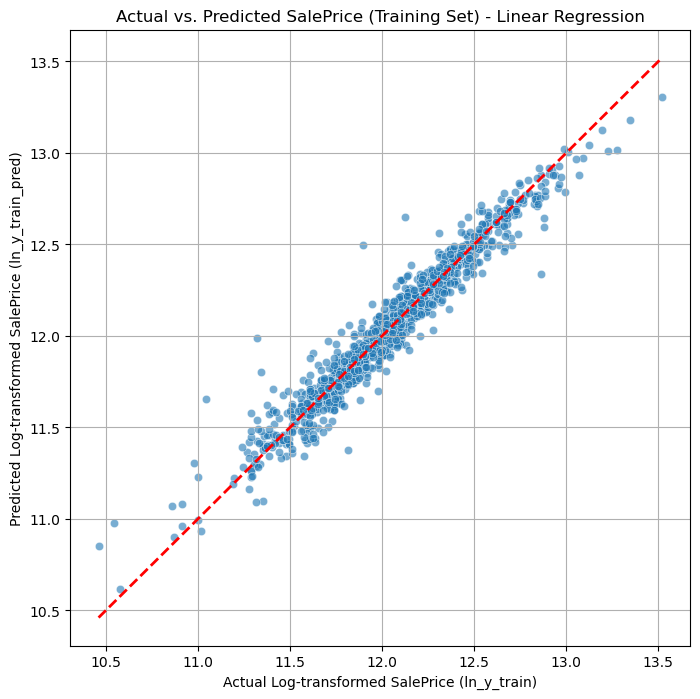

In [9]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_train, y=ln_y_train_pred, alpha=0.6)
plt.plot([min(ln_y_train), max(ln_y_train)], [min(ln_y_train), max(ln_y_train)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_train)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_train_pred)')
plt.title('Actual vs. Predicted SalePrice (Training Set) - Linear Regression')
plt.grid(True)
plt.show()

### Task 2.5. Predict with test set
Use linear_reg_model to generate predictions on X_test,\
store as 'ln_y_test_pred'. \
Print "prediction on test is ready".

In [10]:
ln_y_test_pred = linear_reg_model.predict(X_test_ready)
print("prediction on test is ready")

prediction on test is ready


### Task 2.6.Evaluate with R-squared and MSE on test
Calculate and print the mean squared error and R-squared score comparing ln_y_test and ln_y_test_pred.

In [11]:
mse_test = mean_squared_error(ln_y_test, ln_y_test_pred)
r2_test = r2_score(ln_y_test, ln_y_test_pred)
print(f"Mean Squared Error (Test): {mse_test:.4f}")
print(f"R-squared Score (Test): {r2_test:.4f}")

Mean Squared Error (Test): 0.0151
R-squared Score (Test): 0.9190


### Task 2.7. Visualize Observation and Prediction on train set
 Create a scatter plot with ln_y_test on x-axis and ln_y_test_pred on y-axis, \
 include a 45-degree reference line, set figure size to 8x8,\
 add appropriate labels and title indicating this is for the test set.


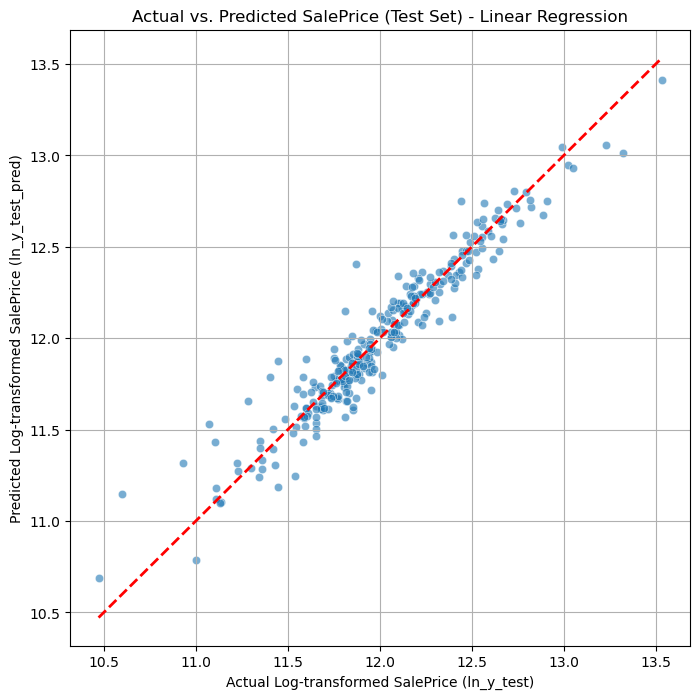

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_test, y=ln_y_test_pred, alpha=0.6)
plt.plot([min(ln_y_test), max(ln_y_test)], [min(ln_y_test), max(ln_y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_test)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_test_pred)')
plt.title('Actual vs. Predicted SalePrice (Test Set) - Linear Regression')
plt.grid(True)
plt.show()

## Task 3. Lasso Regression


### Task 3.1. Model Training
Create and train a Lasso model named 'lasso_model' with alpha parameter set to 0.3, using X_train and ln_y_train. \
Print confirmation message.


In [13]:
lasso_model = Lasso(alpha=0.3, random_state=42)
lasso_model.fit(X_train_ready, ln_y_train)
print("Lasso model training complete.")

Lasso model training complete.


### Task 3.2.Predict with train set
 Use lasso_model to generate predictions on X_train,\
store as 'ln_y_train_pred_lasso'. \
print "prediction on train set is ready"

In [14]:
ln_y_train_pred_lasso = lasso_model.predict(X_train_ready)
print("prediction on train set is ready")

prediction on train set is ready


### Task 3.3.Evaluate with R-squared and MSE on train
Calculate and print mean squared error and R-squared score comparing ln_y_train and ln_y_train_pred_lasso, naming them 'mse_train_lasso' and 'r2_train_lasso'.

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
mse_train_lasso = mean_squared_error(ln_y_train, ln_y_train_pred_lasso)
r2_train_lasso = r2_score(ln_y_train, ln_y_train_pred_lasso)
print(f"Mean Squared Error (Train - Lasso): {mse_train_lasso:.4f}")
print(f"R-squared Score (Train - Lasso): {r2_train_lasso:.4f}")

Mean Squared Error (Train - Lasso): 0.0574
R-squared Score (Train - Lasso): 0.6236


### Task 3.4.Visualize Observation and Prediction on train set
Create a scatter plot with ln_y_train on x-axis and ln_y_train_pred_lasso on y-axis\
include 45-degree reference line, setfigure size 8x8,\
add title indicating Lasso model on training set.

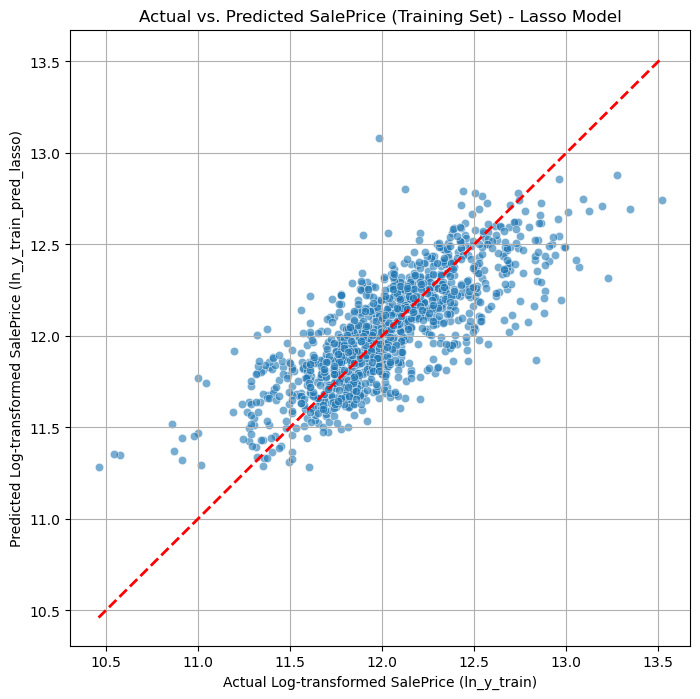

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_train, y=ln_y_train_pred_lasso, alpha=0.6)
plt.plot([min(ln_y_train), max(ln_y_train)], [min(ln_y_train), max(ln_y_train)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_train)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_train_pred_lasso)')
plt.title('Actual vs. Predicted SalePrice (Training Set) - Lasso Model')
plt.grid(True)
plt.show()

### Task 3.5.Predict with test set
Use lasso_model to generate predictions on X_test, \
store as 'ln_y_test_pred_lasso'. \
print “prediction on test set is ready”

In [17]:
ln_y_test_pred_lasso = lasso_model.predict(X_test_ready)
print("prediction on test set is ready")

prediction on test set is ready


### Task 3.6. Evaluate with R-squared and MSE on test
Calculate and print mean squared error and R-squared score comparing ln_y_test and ln_y_test_pred_lasso, naming them 'mse_test_lasso' and 'r2_test_lasso'.

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
mse_test_lasso = mean_squared_error(ln_y_test, ln_y_test_pred_lasso)
r2_test_lasso = r2_score(ln_y_test, ln_y_test_pred_lasso)
print(f"Mean Squared Error (Test - Lasso): {mse_test_lasso:.4f}")
print(f"R-squared Score (Test - Lasso): {r2_test_lasso:.4f}")

Mean Squared Error (Test - Lasso): 0.0721
R-squared Score (Test - Lasso): 0.6134


### Task 3.7. Visualize Observation and Prediction on train set
 Create a scatter plot with y_test on x-axis and ln_y_test_pred_lasso on y-axix\
include 45-degree reference line, figure size 8x8,\
add title indicating Lasso model on test set.

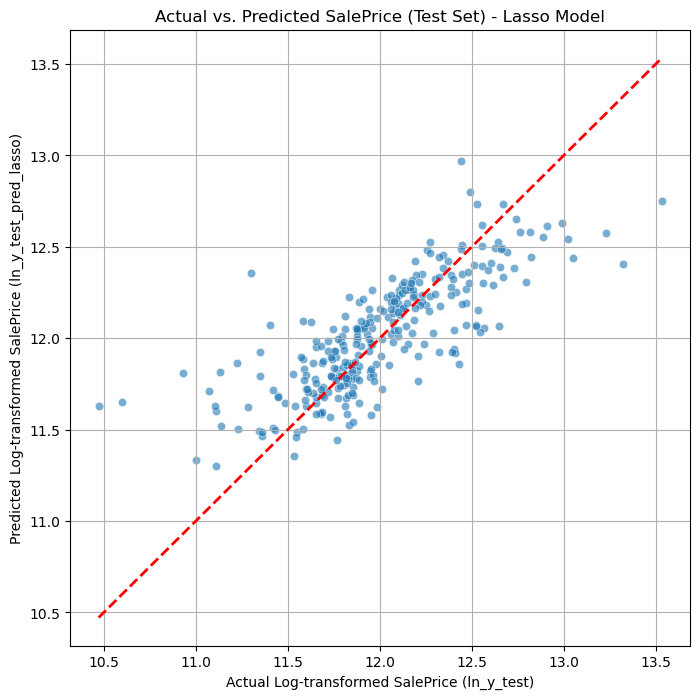

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_test, y=ln_y_test_pred_lasso, alpha=0.6)
plt.plot([min(ln_y_test), max(ln_y_test)], [min(ln_y_test), max(ln_y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_test)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_test_pred_lasso)')
plt.title('Actual vs. Predicted SalePrice (Test Set) - Lasso Model')
plt.grid(True)
plt.show()

### Task 3.8. List important features by sorting coefficients
 Extract coefficients from lasso_model, create a pandas Series with X_train column names as index, sort by absolute value in descending order, select top 10\
 create a bar plot with figure size 12x6, rotating x-axis labels 45 degrees.

/var/folders/8x/c85f6g11487c2zcq5c2v98j80000gn/T/ipykernel_92109/1023401102.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_coefficients.index, y=top_10_coefficients.values, palette='viridis')


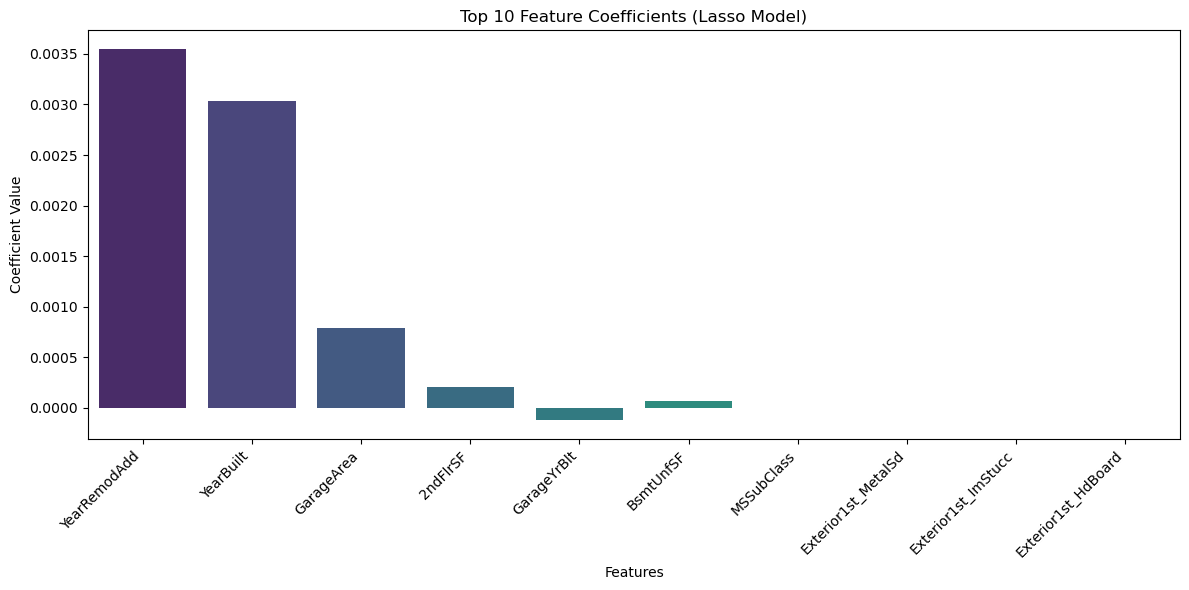

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients and create a Series
lasso_coefficients = pd.Series(lasso_model.coef_, index=X_train_ready.columns)

# Sort by absolute value in descending order and select top 10
top_10_features = lasso_coefficients.abs().sort_values(ascending=False).head(10)

# Get the actual coefficient values for the top features
top_10_coefficients = lasso_coefficients[top_10_features.index]

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_coefficients.index, y=top_10_coefficients.values, palette='viridis')
plt.title('Top 10 Feature Coefficients (Lasso Model)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout()
plt.show()

## Task 4. Decision Tree

### Task 4.1. Model Training
Create and train a DecisionTreeRegressor named 'dt_model' with default parameters using X_train and ln_y_train. Print confirmation message.

In [21]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_ready, ln_y_train)
print("DecisionTreeRegressor model training complete.")

DecisionTreeRegressor model training complete.


### Task 4.2. Predict with train set
Generate predictions on X_train using dt_model, store as 'ln_y_train_pred_dt'.and the print "prediction on test set is ready"


In [22]:
ln_y_train_pred_dt = dt_model.predict(X_train_ready)
print("prediction on train set is ready")

prediction on train set is ready


### Task 4.3. Evaluate with R-squared and MSE on train
 Calculate and print mean squared error and R-squared score by comparing ln_y_train and ln_y_train_pred_dt, naming them 'mse_train_dt' and 'r2_train_dt'.

In [23]:
mse_train_dt = mean_squared_error(ln_y_train, ln_y_train_pred_dt)
r2_train_dt = r2_score(ln_y_train, ln_y_train_pred_dt)
print(f"Mean Squared Error (Train - Decision Tree): {mse_train_dt:.4f}")
print(f"R-squared Score (Train - Decision Tree): {r2_train_dt:.4f}")

Mean Squared Error (Train - Decision Tree): 0.0000
R-squared Score (Train - Decision Tree): 1.0000


### Task 4.4. Visualize Observation and Prediction on train set
 Create a scatter plot with y_train on x-axis and ln_y_train_pred_dt on y-axix\
include 45-degree reference line, figure size 8x8,\
add title indicating Decision Tree model on test set.

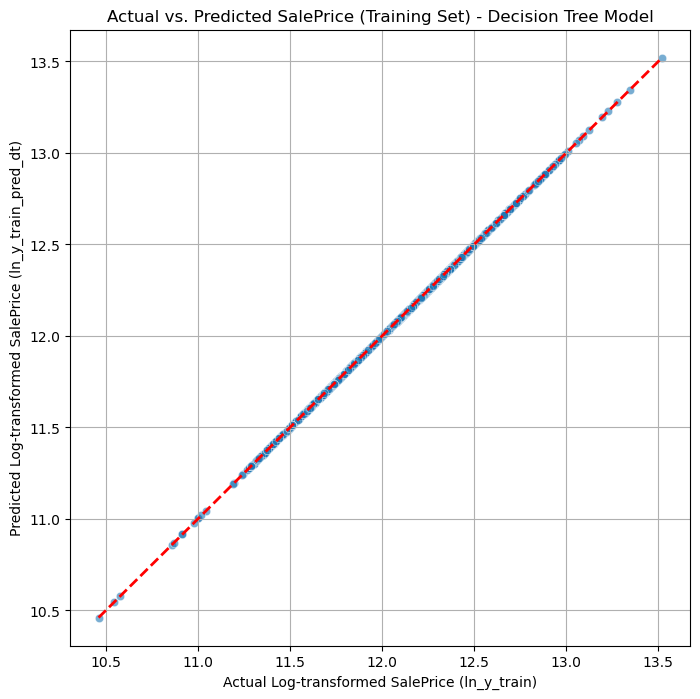

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_train, y=ln_y_train_pred_dt, alpha=0.6)
plt.plot([min(ln_y_train), max(ln_y_train)], [min(ln_y_train), max(ln_y_train)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_train)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_train_pred_dt)')
plt.title('Actual vs. Predicted SalePrice (Training Set) - Decision Tree Model')
plt.grid(True)
plt.show()

### Task 4.5. Predict with test set
Generate predictions on X_test using dt_model, store as 'ln_y_test_pred_dt'. Print confirmation message.

In [25]:
ln_y_test_pred_dt = dt_model.predict(X_test_ready)
print("prediction on test set is ready")

prediction on test set is ready


### Task 4.6. Evaluate with R-squared and MSE on test
Calculate and print mean squared error and R-squared score by comparing ln_y_test and ln_y_test_pred_dt, naming them 'mse_test_dt' and 'r2_test_dt'.

In [26]:
mse_test_dt = mean_squared_error(ln_y_test, ln_y_test_pred_dt)
r2_test_dt = r2_score(ln_y_test, ln_y_test_pred_dt)
print(f"Mean Squared Error (Test - Decision Tree): {mse_test_dt:.4f}")
print(f"R-squared Score (Test - Decision Tree): {r2_test_dt:.4f}")

Mean Squared Error (Test - Decision Tree): 0.0398
R-squared Score (Test - Decision Tree): 0.7866


### Task 4.7. Visualize Observation and Prediction on train set
Create a scatter plot with y_test on x-axis and ln_y_test_pred_dt on y-axix\
include 45-degree reference line, figure size 8x8,\
add title indicating Decision Tree model on test set.

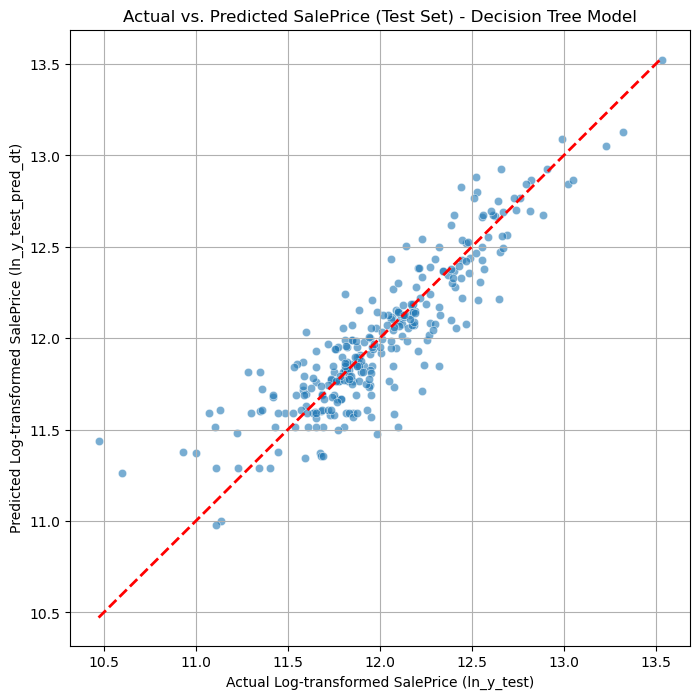

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_test, y=ln_y_test_pred_dt, alpha=0.6)
plt.plot([min(ln_y_test), max(ln_y_test)], [min(ln_y_test), max(ln_y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_test)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_test_pred_dt)')
plt.title('Actual vs. Predicted SalePrice (Test Set) - Decision Tree Model')
plt.grid(True)
plt.show()

### Task 4.8.Examine feature importance
 Extract feature importances from dt_model, create pandas Series with feature names as index, sort descending, select top 10 features, create bar plot with figure size 12x6.

/var/folders/8x/c85f6g11487c2zcq5c2v98j80000gn/T/ipykernel_92109/4227677320.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_dt_features.index, y=top_10_dt_features.values, palette='viridis')


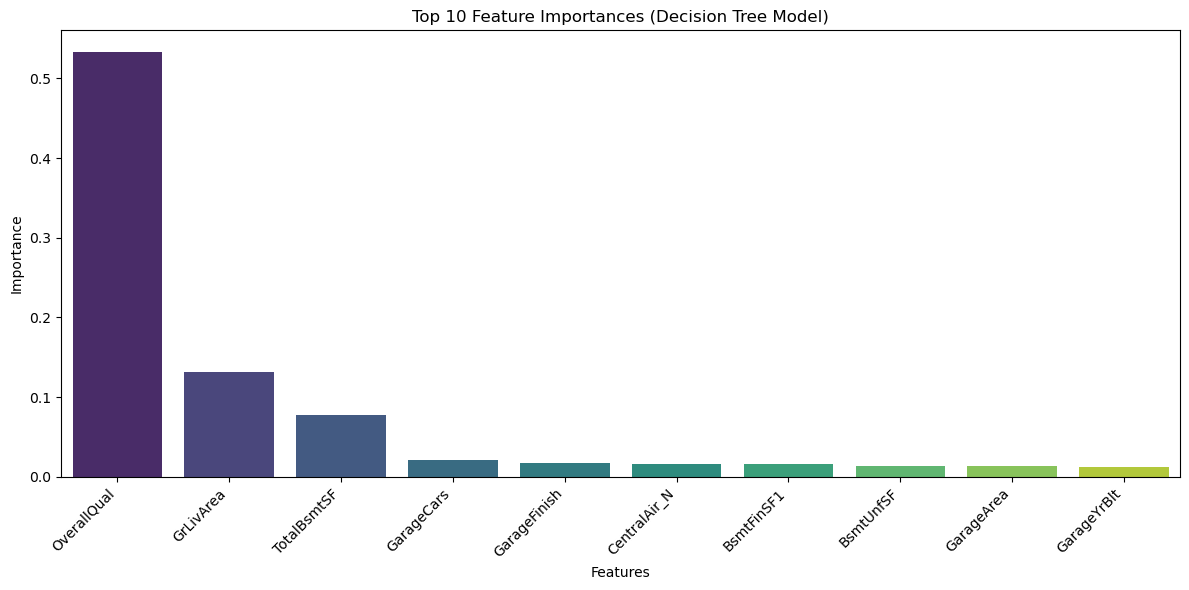

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances and create a Series
dt_feature_importances = pd.Series(dt_model.feature_importances_, index=X_train_ready.columns)

# Sort in descending order and select top 10
top_10_dt_features = dt_feature_importances.sort_values(ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_dt_features.index, y=top_10_dt_features.values, palette='viridis')
plt.title('Top 10 Feature Importances (Decision Tree Model)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout()
plt.show()

### Task 4.9. Manual adust paramter to retrain the model

 Create and train a new DecisionTreeRegressor named 'dt_model_depth4' with max_depth parameter set to 4, using X_train and y_train. \
 Print confirmation message.

In [29]:
dt_model_depth4 = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model_depth4.fit(X_train_ready, ln_y_train)
print("DecisionTreeRegressor model (max_depth=4) training complete.")

DecisionTreeRegressor model (max_depth=4) training complete.


### Task 4.10. Automation
Repeat Task 4.2-4.7 for dt_model_depth4, using appropriate variable names with '_depth4' suffix.

prediction on train set for dt_model_depth4 is ready
Mean Squared Error (Train - Decision Tree Depth 4): 0.0338
R-squared Score (Train - Decision Tree Depth 4): 0.7781


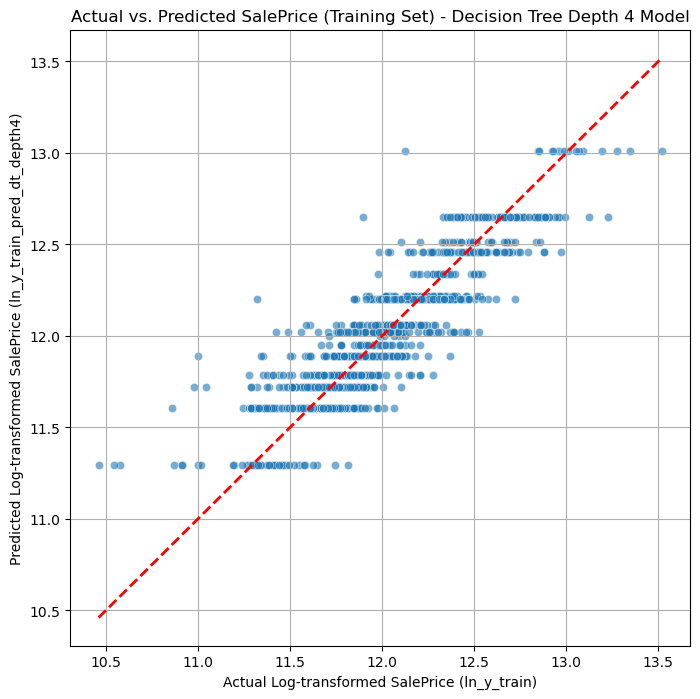

prediction on test set for dt_model_depth4 is ready
Mean Squared Error (Test - Decision Tree Depth 4): 0.0435
R-squared Score (Test - Decision Tree Depth 4): 0.7666


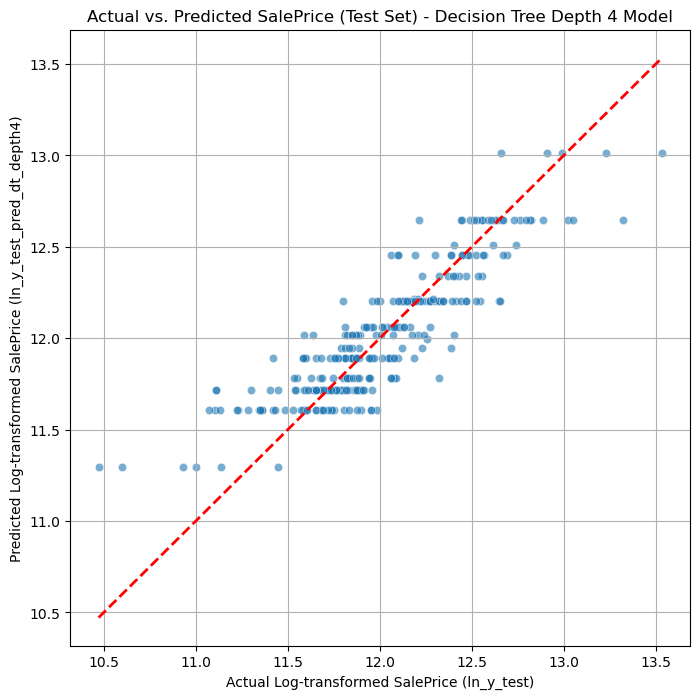

In [30]:
# Task 4.2. Predict with train set for dt_model_depth4
ln_y_train_pred_dt_depth4 = dt_model_depth4.predict(X_train_ready)
print("prediction on train set for dt_model_depth4 is ready")

# Task 4.3. Evaluate with R-squared and MSE on train for dt_model_depth4
mse_train_dt_depth4 = mean_squared_error(ln_y_train, ln_y_train_pred_dt_depth4)
r2_train_dt_depth4 = r2_score(ln_y_train, ln_y_train_pred_dt_depth4)
print(f"Mean Squared Error (Train - Decision Tree Depth 4): {mse_train_dt_depth4:.4f}")
print(f"R-squared Score (Train - Decision Tree Depth 4): {r2_train_dt_depth4:.4f}")

# Task 4.4. Visualize Observation and Prediction on train set for dt_model_depth4
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_train, y=ln_y_train_pred_dt_depth4, alpha=0.6)
plt.plot([min(ln_y_train), max(ln_y_train)], [min(ln_y_train), max(ln_y_train)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_train)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_train_pred_dt_depth4)')
plt.title('Actual vs. Predicted SalePrice (Training Set) - Decision Tree Depth 4 Model')
plt.grid(True)
plt.show()

# Task 4.5. Predict with test set for dt_model_depth4
ln_y_test_pred_dt_depth4 = dt_model_depth4.predict(X_test_ready)
print("prediction on test set for dt_model_depth4 is ready")

# Task 4.6. Evaluate with R-squared and MSE on test for dt_model_depth4
mse_test_dt_depth4 = mean_squared_error(ln_y_test, ln_y_test_pred_dt_depth4)
r2_test_dt_depth4 = r2_score(ln_y_test, ln_y_test_pred_dt_depth4)
print(f"Mean Squared Error (Test - Decision Tree Depth 4): {mse_test_dt_depth4:.4f}")
print(f"R-squared Score (Test - Decision Tree Depth 4): {r2_test_dt_depth4:.4f}")

# Task 4.7. Visualize Observation and Prediction on test set for dt_model_depth4
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_test, y=ln_y_test_pred_dt_depth4, alpha=0.6)
plt.plot([min(ln_y_test), max(ln_y_test)], [min(ln_y_test), max(ln_y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_test)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_test_pred_dt_depth4)')
plt.title('Actual vs. Predicted SalePrice (Test Set) - Decision Tree Depth 4 Model')
plt.grid(True)
plt.show()

### Task 4.11. Describe what you observed by comparing dt_model and dt_model_depth4

In [ ]:
print(f"{'Model':<20}{'Train R2':>12}{'Train MSE':>12}{'Test R2':>12}{'Test MSE':>12}")
print(f"{'dt_model':<20}{r2_train_dt:>12.4f}{mse_train_dt:>12.4f}{r2_test_dt:>12.4f}{mse_test_dt:>12.4f}")
print(f"{'dt_model_depth4':<20}{r2_train_dt_depth4:>12.4f}{mse_train_dt_depth4:>12.4f}{r2_test_dt_depth4:>12.4f}{mse_test_dt_depth4:>12.4f}")

print("""
Observations:
- dt_model (unrestricted depth) achieves a near-perfect fit on the training set (R2 ~= 1.00, MSE ~= 0.00),
  but its test R2 drops to ~0.79. The large gap between train and test performance shows the tree grew deep
  enough to memorize the training data, i.e. it overfit.
- dt_model_depth4 (max_depth=4) has a much lower train R2 (~0.78), close to its own test R2 (~0.77). The
  train-test gap nearly disappears, meaning the shallower tree overfits far less.
- Test performance is roughly similar for both models (R2 ~0.79 vs ~0.77), so limiting depth costs little to
  no test accuracy while producing a model that generalizes much more consistently and is also simpler/less
  prone to overfitting on new data.
""")

## Task 5. Random Forest Model

### Task 5.1. Model Training
Create and train a RandomForestRegressor named 'rf_model' with parameters: n_estimators=100, max_depth=6, max_features='log2', random_state=42. Use X_train and y_train. Print confirmation message.


In [31]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, max_features='log2', random_state=42)
rf_model.fit(X_train_ready, ln_y_train)
print("RandomForestRegressor model training complete.")

RandomForestRegressor model training complete.


### Task 5.2. Predict with train set
Generate predictions on X_train using rf_model, store as 'y_train_pred_rf'.

In [32]:
y_train_pred_rf = rf_model.predict(X_train_ready)

### Task 5.3. Evaluate with R-squared and MSE on train
Calculate and print MSE and R-squared for training set by comparing y_train and y_train_pred_rf, naming them 'mse_train_rf' and 'r2_train_rf'.


In [33]:
mse_train_rf = mean_squared_error(ln_y_train, y_train_pred_rf)
r2_train_rf = r2_score(ln_y_train, y_train_pred_rf)
print(f"Mean Squared Error (Train - Random Forest): {mse_train_rf:.4f}")
print(f"R-squared Score (Train - Random Forest): {r2_train_rf:.4f}")

Mean Squared Error (Train - Random Forest): 0.0232
R-squared Score (Train - Random Forest): 0.8475


 ### Task 5.4. Visualize Observation and Prediction on train set
 Create scatter plot for training set with observed vs predicted values, 45-degree line, figure size 8x8.

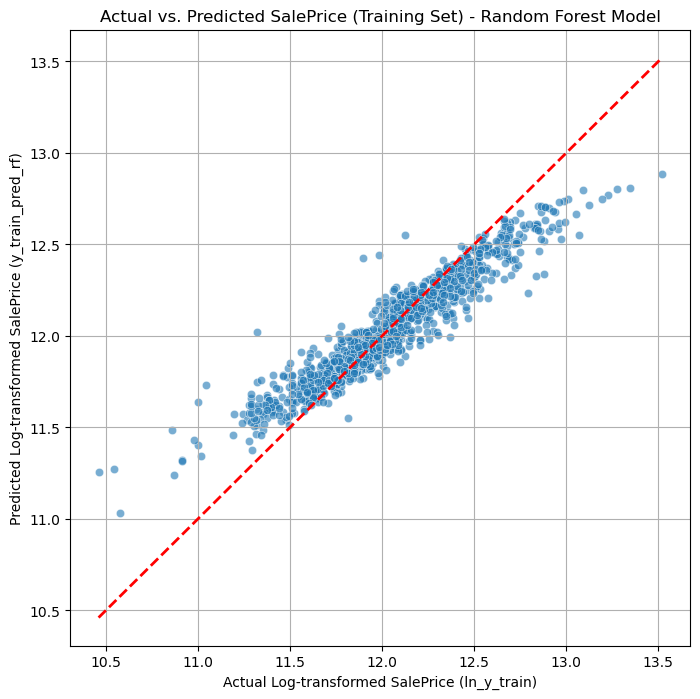

In [34]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_train, y=y_train_pred_rf, alpha=0.6)
plt.plot([min(ln_y_train), max(ln_y_train)], [min(ln_y_train), max(ln_y_train)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_train)')
plt.ylabel('Predicted Log-transformed SalePrice (y_train_pred_rf)')
plt.title('Actual vs. Predicted SalePrice (Training Set) - Random Forest Model')
plt.grid(True)
plt.show()

### Task 5.5. Predict with test
Generate predictions on X_test using rf_model, store as 'y_test_pred_rf'.

In [35]:
y_test_pred_rf = rf_model.predict(X_test_ready)

### Task 5.6. Evaluate with R-squared and MSE on test
Calculate and print MSE and R-squared for test set by comparing y_test and y_test_pred_rf, naming them 'mse_test_rf' and 'r2_test_rf'.

In [36]:
mse_test_rf = mean_squared_error(ln_y_test, y_test_pred_rf)
r2_test_rf = r2_score(ln_y_test, y_test_pred_rf)
print(f"Mean Squared Error (Test - Random Forest): {mse_test_rf:.4f}")
print(f"R-squared Score (Test - Random Forest): {r2_test_rf:.4f}")

Mean Squared Error (Test - Random Forest): 0.0395
R-squared Score (Test - Random Forest): 0.7883


### Task 5.7 Visualize Observation and Prediction on train set
Create scatter plot for test set with observed vs predicted values, 45-degree line, figure size 8x8.

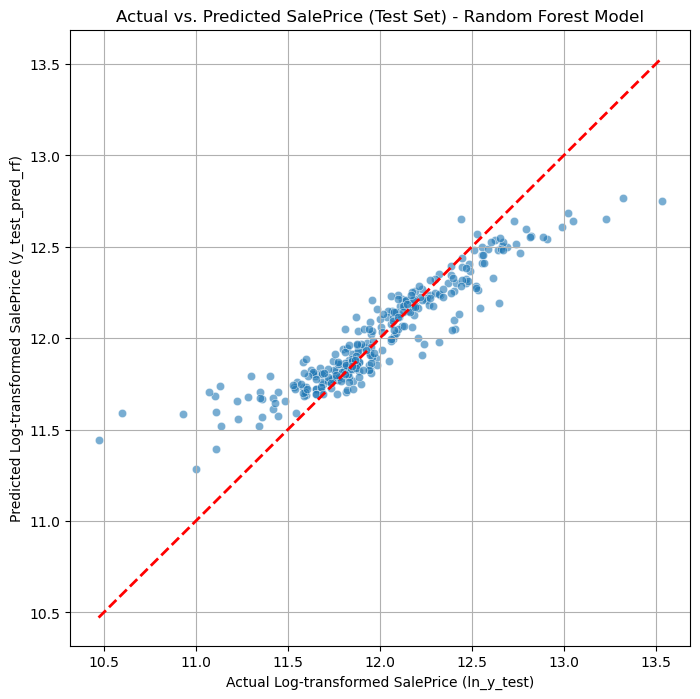

In [37]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_test, y=y_test_pred_rf, alpha=0.6)
plt.plot([min(ln_y_test), max(ln_y_test)], [min(ln_y_test), max(ln_y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_test)')
plt.ylabel('Predicted Log-transformed SalePrice (y_test_pred_rf)')
plt.title('Actual vs. Predicted SalePrice (Test Set) - Random Forest Model')
plt.grid(True)
plt.show()

### Task 5.8 Evaluate Feature Importance
Extract feature importances from rf_model, create pandas Series, sort descending, select top 10, create bar plot titled "Top 10 Feature Importances (Random Forest)".

/var/folders/8x/c85f6g11487c2zcq5c2v98j80000gn/T/ipykernel_92109/4002773496.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_rf_features.index, y=top_10_rf_features.values, palette='viridis')


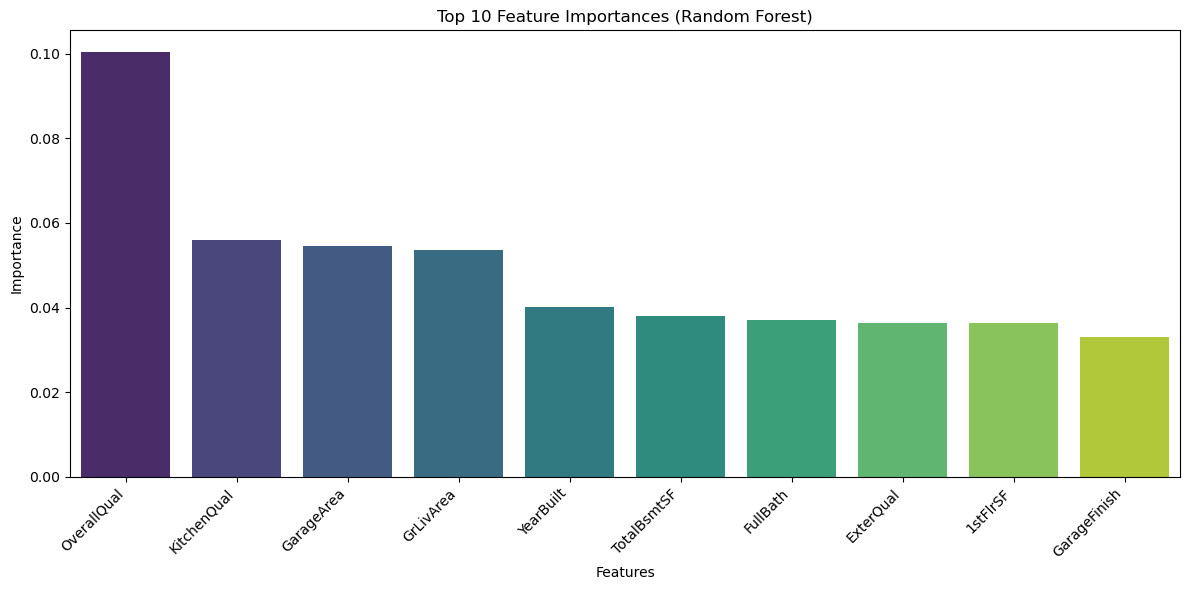

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances and create a Series
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=X_train_ready.columns)

# Sort in descending order and select top 10
top_10_rf_features = rf_feature_importances.sort_values(ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_rf_features.index, y=top_10_rf_features.values, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout()
plt.show()

## Task 6. Gradient Boosting Model


### Task 6.1. Model training
Create and train a GradientBoostingRegressor named 'gbr_model' with parameters: n_estimators=100, max_depth=4, max_features='sqrt', learning_rate=0.08, subsample=1, random_state=42. Use X_train and y_train.

In [39]:
gbr_model = GradientBoostingRegressor(n_estimators=100, max_depth=4, max_features='sqrt', learning_rate=0.08, subsample=1, random_state=42)
gbr_model.fit(X_train_ready, ln_y_train)
print("GradientBoostingRegressor model training complete.")

GradientBoostingRegressor model training complete.


### Task 6.2. Predict with train set
Generate predictions on X_train using gbr_model, store as 'y_train_pred_gbr'.

In [40]:
y_train_pred_gbr = gbr_model.predict(X_train_ready)

### Task 6.3. Evaluate with R-squared and MSE on train
 Calculate and print MSE and R-squared for training set by comparing ln_y_train with ln_y_train_pred_gbr, naming them 'mse_train_gbr' and 'r2_train_gbr'.

In [41]:
mse_train_gbr = mean_squared_error(ln_y_train, y_train_pred_gbr)
r2_train_gbr = r2_score(ln_y_train, y_train_pred_gbr)
print(f"Mean Squared Error (Train - Gradient Boosting): {mse_train_gbr:.4f}")
print(f"R-squared Score (Train - Gradient Boosting): {r2_train_gbr:.4f}")

Mean Squared Error (Train - Gradient Boosting): 0.0063
R-squared Score (Train - Gradient Boosting): 0.9589


### Task 6.4. Visualize Observation and Prediction on train set
 Create scatter plot for training set with observed vs predicted values, 45-degree line, figure size 8x8.

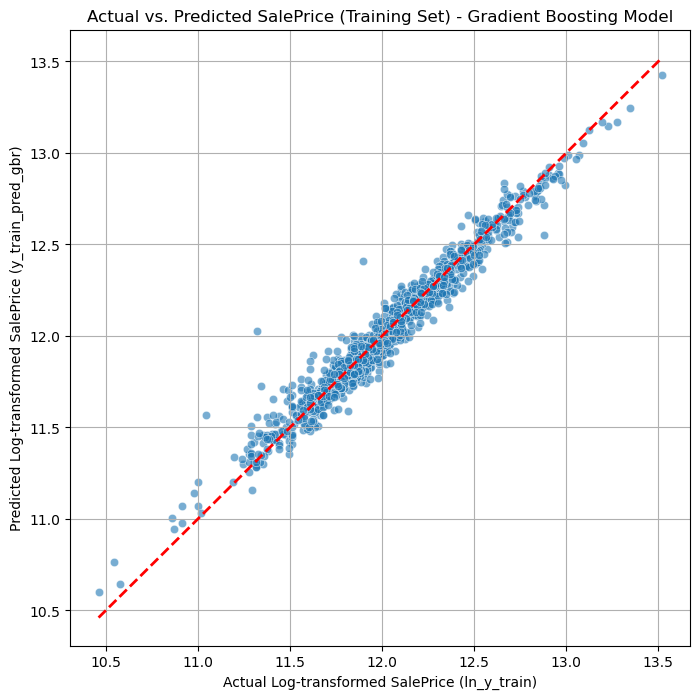

In [42]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_train, y=y_train_pred_gbr, alpha=0.6)
plt.plot([min(ln_y_train), max(ln_y_train)], [min(ln_y_train), max(ln_y_train)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_train)')
plt.ylabel('Predicted Log-transformed SalePrice (y_train_pred_gbr)')
plt.title('Actual vs. Predicted SalePrice (Training Set) - Gradient Boosting Model')
plt.grid(True)
plt.show()

### Task 6.5. Predict with test set
Generate predictions on X_test using gbr_model, store as 'ln_y_test_pred_gbr'.

In [43]:
ln_y_test_pred_gbr = gbr_model.predict(X_test_ready)

### Task 6.6. Evaluate with R-squared and MSE on test
 Calculate and print MSE and R-squared for training set by comparing ln_y_train with ln_y_test_pred_gbr, naming them 'mse_test_gbr' and 'r2_test_gbr'.

In [44]:
mse_test_gbr = mean_squared_error(ln_y_test, ln_y_test_pred_gbr)
r2_test_gbr = r2_score(ln_y_test, ln_y_test_pred_gbr)
print(f"Mean Squared Error (Test - Gradient Boosting): {mse_test_gbr:.4f}")
print(f"R-squared Score (Test - Gradient Boosting): {r2_test_gbr:.4f}")

Mean Squared Error (Test - Gradient Boosting): 0.0193
R-squared Score (Test - Gradient Boosting): 0.8964


### Task 6.7 Visualize Observation and Prediction on train set
Create scatter plot for test set with observed vs predicted values, 45-degree line, figure size 8x8.

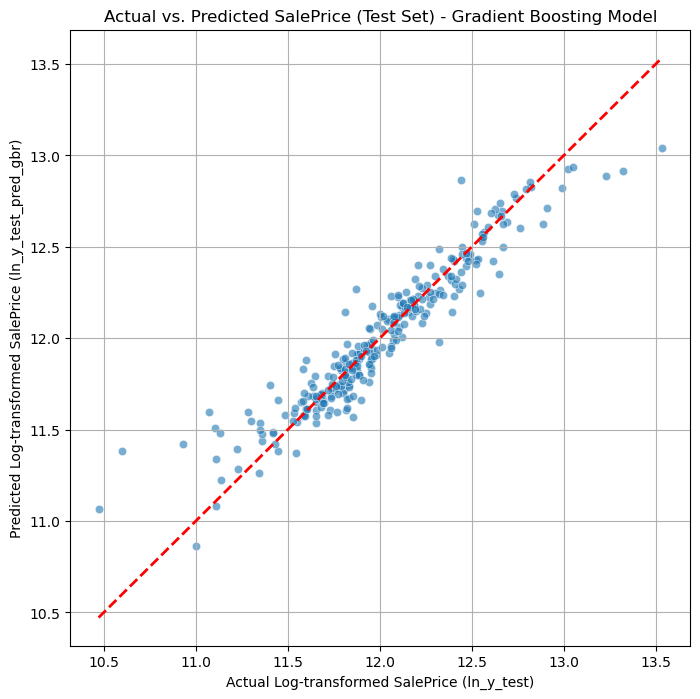

In [45]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_test, y=ln_y_test_pred_gbr, alpha=0.6)
plt.plot([min(ln_y_test), max(ln_y_test)], [min(ln_y_test), max(ln_y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_test)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_test_pred_gbr)')
plt.title('Actual vs. Predicted SalePrice (Test Set) - Gradient Boosting Model')
plt.grid(True)
plt.show()

### Task 6.8 Evaluate Feature Importance
Extract feature importances from gbr_model, create pandas Series, sort descending, select top 10, create bar plot titled "Top 10 Feature Importances (Gradient Boosting)".

/var/folders/8x/c85f6g11487c2zcq5c2v98j80000gn/T/ipykernel_92109/3162051105.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_gbr_features.index, y=top_10_gbr_features.values, palette='viridis')


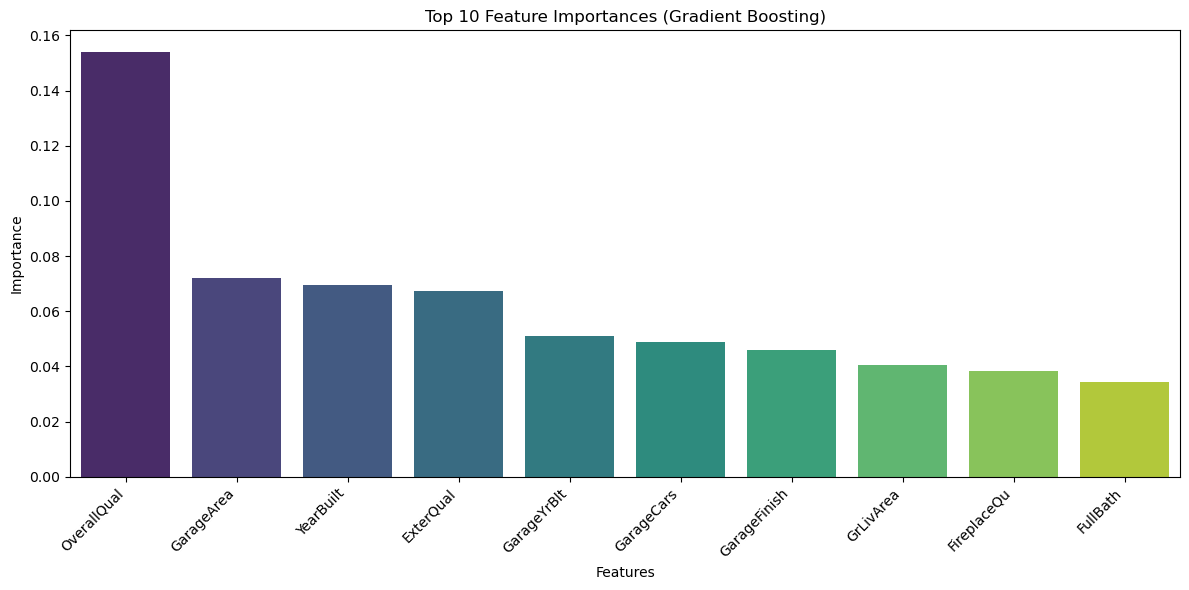

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances and create a Series
gbr_feature_importances = pd.Series(gbr_model.feature_importances_, index=X_train_ready.columns)

# Sort in descending order and select top 10
top_10_gbr_features = gbr_feature_importances.sort_values(ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_gbr_features.index, y=top_10_gbr_features.values, palette='viridis')
plt.title('Top 10 Feature Importances (Gradient Boosting)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout()
plt.show()

## Task 7. Hyperparameter Tuning with Grid Search

### Task 7.1. Define parameter space
Define a parameter grid dictionary named 'parameters' with the following specifications:

*   learning_rate: values 0.05, 0.08, 0.1, 0.15
*   max_depth: values 3, 4, 5, 6, 8
*   n_estimators: values 30, 50, 100
*   max_features: values "log2", "sqrt"
*   max_leaf_nodes: values 8, 16, 32, 64
*   subsample: values 0.8, 1
*   random_state: value 42

In [47]:
parameters = {
    'learning_rate': [0.05, 0.08, 0.1, 0.15],
    'max_depth': [3, 4, 5, 6, 8],
    'n_estimators': [30, 50, 100],
    'max_features': ['log2', 'sqrt'],
    'max_leaf_nodes': [8, 16, 32, 64],
    'subsample': [0.8, 1],
    'random_state': [42]
}

### Task 7.2. Create a base model
Create a base GradientBoostingRegressor instance named 'gbr'.

In [48]:
gbr = GradientBoostingRegressor(random_state=42)

### Task 7.3. Create the Grid Search Object
Create a GridSearchCV object named 'grid_search' using gbr and parameters, with 5-fold cross-validation, scoring metric as negative mean squared error, and parallel processing enabled.


In [49]:
grid_search = GridSearchCV(estimator=gbr,
                           param_grid=parameters,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1)

### Task 7.4. Model Training
Fit grid_search on X_train and y_train.

In [50]:
grid_search.fit(X_train_ready, ln_y_train)

/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.08, 0.1, 0.15],
                         'max_depth': [3, 4, 5, 6, 8],
                         'max_features': ['log2', 'sqrt'],
                         'max_leaf_nodes': [8, 16, 32, 64],
                         'n_estimators': [30, 50, 100], 'random_state': [42],
                         'subsample': [0.8, 1]},
             scoring='neg_mean_squared_error')

### Task 7.5. get the best estimator


In [51]:
best_gbr_model = grid_search.best_estimator_
print("Best Gradient Boosting Regressor Model:")
print(best_gbr_model)

Best Gradient Boosting Regressor Model:
GradientBoostingRegressor(learning_rate=0.08, max_depth=8, max_features='sqrt',
                          max_leaf_nodes=32, random_state=42, subsample=0.8)


### Task 7.6. Make predictions on the training set using the best estimator
Extract the best estimator from grid_search and store as 'best_gbr_model', and calculate the R-squared on the train set



In [ ]:
# Make predictions on training set using best estimator
best_gbr_train_pred = best_gbr_model.predict(X_train_ready)

# Calculate R-squared on training set
best_gbr_r2_train = r2_score(ln_y_train, best_gbr_train_pred)
print(f"Best GBR Model - R-squared Score (Train): {best_gbr_r2_train:.4f}")

### Task 7.6. Predict with test set
Use best_gbr_model to generate predictions on X_test, store as 'ln_y_test_pred_best_gbr'. Print confirmation message.

In [ ]:
ln_y_test_pred_best_gbr = best_gbr_model.predict(X_test_ready)
print("prediction on test set is ready")

### Task 7.7. Evaluate with R-squared on test
Calculate and print MSE and R-squared comparing y_test and ln_y_test_pred_best_gbr, naming them 'mse_test_best_gbr' and 'r2_test_best_gbr'.

In [ ]:
mse_test_best_gbr = mean_squared_error(ln_y_test, ln_y_test_pred_best_gbr)
r2_test_best_gbr = r2_score(ln_y_test, ln_y_test_pred_best_gbr)
print(f"Mean Squared Error (Test - Best GBR): {mse_test_best_gbr:.4f}")
print(f"R-squared Score (Test - Best GBR): {r2_test_best_gbr:.4f}")

### Task 7.8. Visualize Observation and Prediction on train set
Create scatter plot for test set with observed vs predicted values, 45-degree line, figure size 8x8.
title indicating "Best Gradient Boosting Regressor".

In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=ln_y_test, y=ln_y_test_pred_best_gbr, alpha=0.6)
plt.plot([min(ln_y_test), max(ln_y_test)], [min(ln_y_test), max(ln_y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Log-transformed SalePrice (ln_y_test)')
plt.ylabel('Predicted Log-transformed SalePrice (ln_y_test_pred_best_gbr)')
plt.title('Actual vs. Predicted SalePrice (Test Set) - Best Gradient Boosting Regressor')
plt.grid(True)
plt.show()

### Task 7.9. Evaluate Feature Importance
Extract and plot top 10 feature importances from best_gbr_model as bar chart with appropriate title.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances and create a Series
best_gbr_feature_importances = pd.Series(best_gbr_model.feature_importances_, index=X_train_ready.columns)

# Sort in descending order and select top 10
top_10_best_gbr_features = best_gbr_feature_importances.sort_values(ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_best_gbr_features.index, y=top_10_best_gbr_features.values, palette='viridis')
plt.title('Top 10 Feature Importances (Best Gradient Boosting Regressor)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout()
plt.show()

###